# 02 — EDA sobre anotaciones

Exploración de las anotaciones de la *VitalDB Arrhythmia Database* con foco en la variable objetivo `rhythm_label`.

**Objetivos**

1. Cargar todas las anotaciones disponibles y unirlas con metadata por `case_id`.
2. Distribución global de `rhythm_label` y desbalance entre clases.
3. Conteo por caso: cuántos latidos por `case_id`, cuántos por `rhythm_label`.
4. Distribución de `bad_signal_quality` y solapamiento con `rhythm_label`.
5. Análisis descriptivo **complementario** de `beat_type`.

**Restricción metodológica**

`beat_type` solo se analiza en modo descriptivo. **No se usa como variable predictora en ningún experimento.** Cualquier estadística sobre `beat_type` aquí es exploratoria.

**Filtros base**

- Excluir registros con `bad_signal_quality`.
- Excluir la clase `Noise`.

## 1. Setup

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loading import load_metadata, load_all_annotations, merge_metadata_and_annotations
from src.preprocessing import apply_basic_filters, exclude_bad_signal_quality, exclude_rhythm_labels

sns.set_theme(context="notebook", style="whitegrid")

## 2. Carga y merge

In [6]:
metadata = load_metadata()
annotations = load_all_annotations()  # carga todos los archivos disponibles

print("Metadata shape:", metadata.shape)
print("Anotaciones shape:", annotations.shape)

merged = merge_metadata_and_annotations(metadata, annotations, on=config.CASE_ID_COLUMN, how="inner")
print("Merge shape:", merged.shape)
merged.head()

Metadata shape: (482, 79)
Anotaciones shape: (676250, 7)
Merge shape: (676250, 85)


,time_second,beat_type,rhythm_label,bad_signal_quality,bad_signal_quality_label,case_id,caseid,analysis_start_time_sec,analysis_end_time_sec,analyzed_duration_sec,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,4993.494444,N,N,False,NaN,1001,NaN,4993.494444,6188.511111,1195.016667,...,0,0,0.0,0,60,0,10,80,0,300
1,4994.586111,N,N,False,NaN,1001,NaN,4993.494444,6188.511111,1195.016667,...,0,0,0.0,0,60,0,10,80,0,300
2,4995.672222,N,N,False,NaN,1001,NaN,4993.494444,6188.511111,1195.016667,...,0,0,0.0,0,60,0,10,80,0,300
3,4996.788889,N,N,False,NaN,1001,NaN,4993.494444,6188.511111,1195.016667,...,0,0,0.0,0,60,0,10,80,0,300
4,4998.036111,N,N,False,NaN,1001,NaN,4993.494444,6188.511111,1195.016667,...,0,0,0.0,0,60,0,10,80,0,300


## 3. Aplicación de filtros base

In [7]:
filtered = apply_basic_filters(
    merged,
    target_column=config.TARGET_COLUMN,
    signal_quality_column=config.SIGNAL_QUALITY_COLUMN,
    excluded_labels=config.EXCLUDED_RHYTHM_LABELS,
)
print("Filas antes:", len(merged))
print("Filas después de filtros base:", len(filtered))

Filas antes: 676250
Filas después de filtros base: 640274


## 4. Distribución global de `rhythm_label`

In [8]:
rhythm_counts = filtered[config.TARGET_COLUMN].value_counts(dropna=False)
rhythm_counts

rhythm_label
N                               392623
AFIB/AFL                        158480
Patterned Ventricular Ectopy     23902
SND                              22224
Patterned Atrial Ectopy          19946
WAP/MAT                          10047
SVTA                              6413
AVB                               4193
VT                                1573
NaN                                814
Unclassifiable                      59
Name: count, dtype: int64

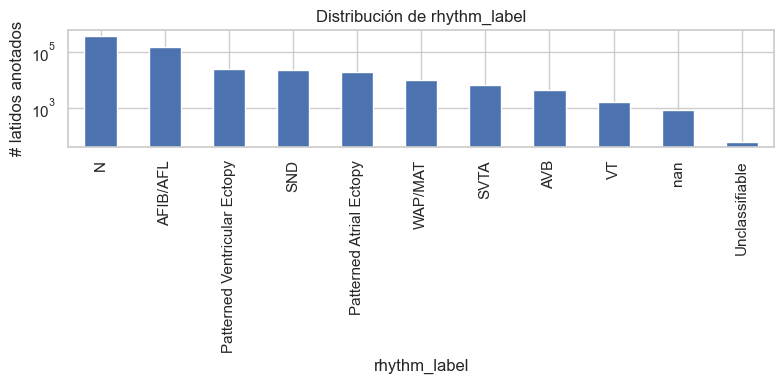

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
rhythm_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribución de rhythm_label")
ax.set_xlabel("rhythm_label")
ax.set_ylabel("# latidos anotados")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 5. Conteos por `case_id`

In [10]:
beats_per_case = filtered.groupby(config.CASE_ID_COLUMN).size().sort_values(ascending=False)
print("Casos únicos:", beats_per_case.shape[0])
beats_per_case.describe()

Casos únicos: 482


count     482.000000
mean     1328.369295
std       423.516180
min       173.000000
25%      1075.500000
50%      1302.000000
75%      1560.000000
max      4712.000000
dtype: float64

In [11]:
rhythms_per_case = (
    filtered.groupby([config.CASE_ID_COLUMN, config.TARGET_COLUMN]).size().unstack(fill_value=0)
)
rhythms_per_case.head()

rhythm_label,AFIB/AFL,AVB,N,Patterned Atrial Ectopy,Patterned Ventricular Ectopy,SND,SVTA,Unclassifiable,VT,WAP/MAT
case_id,,,,,,,,,,
12,0,0,983,0,123,0,0,0,0,0
13,0,0,670,0,623,0,0,0,0,0
19,0,0,1645,0,0,0,6,0,0,0
42,0,0,1146,0,16,0,0,0,0,0
96,0,0,1554,0,0,0,0,0,0,0


## 6. Calidad de señal (`bad_signal_quality`)

Comparar conteos antes y después de aplicar `exclude_bad_signal_quality` sobre los datos no filtrados.

In [12]:
before = len(merged)
after = len(exclude_bad_signal_quality(merged, column=config.SIGNAL_QUALITY_COLUMN))
print("Antes:", before, "Después de excluir bad_signal_quality:", after)

Antes: 676250 Después de excluir bad_signal_quality: 641282


## 7. `beat_type` (análisis descriptivo complementario)

> Solo descriptivo. No se utiliza como predictor en los modelos.

In [13]:
if config.BEAT_TYPE_COLUMN in filtered.columns:
    print(filtered[config.BEAT_TYPE_COLUMN].value_counts(dropna=False))
else:
    print(f"La columna '{config.BEAT_TYPE_COLUMN}' no está disponible en los datos cargados.")

beat_type
N      436503
S      183053
V       16098
U        4456
NaN       157
P           7
Name: count, dtype: int64


## 8. Próximos pasos

- Pasar a `03_ecg_loading_and_visualization.ipynb` para cargar señales crudas desde VitalDB para un subconjunto reducido de `case_id`.